# Prévision de la demande touristique & recommandation de destinations
**Analyse exploratoire — fiabilisation — GOLD DATA — modélisation**

Workflow respecté : compréhension métier → audit → AED → nettoyage → GOLD DATA → modélisation → recommandation.

> ⚠️ **Constat clé de l'audit** : le fichier `05_cible_recommandation.csv` ne contient **aucune donnée structurée** (texte libre, pas de colonnes exploitables). **Il n'existe donc pas de variable cible de recommandation** : la recommandation est traitée comme un **problème non supervisé** — un score raisonné sous contraintes — et non une prédiction supervisée.

In [1]:
import json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.figsize':(9,3.2),'axes.grid':True,'grid.alpha':.3,'font.size':9})
DATA_DIR = Path(".")   # placez les 6 fichiers sources dans ce dossier

## 1. Chargement des données

In [2]:
dest = pd.read_csv(DATA_DIR/'01_destinations_brut.csv')
sig  = pd.read_excel(DATA_DIR/'02_signaux_marche.xlsx')
rev  = pd.DataFrame(json.load(open(DATA_DIR/'03_reviews_reseaux.json', encoding='utf-8')))
ext  = pd.read_csv(DATA_DIR/'04_facteurs_externes.csv', sep=';')   # séparateur non standard ';'
camp = pd.DataFrame(json.load(open(DATA_DIR/'06_campaign_history.json', encoding='utf-8')))

_cible = open(DATA_DIR/'05_cible_recommandation.csv', encoding='utf-8').read()
print(f'05_cible_recommandation.csv : {len(_cible)} caractères de texte libre, aucune donnée structurée -> pas de variable cible')
print('\n--- dimensions des sources exploitables ---')
for n,df in [('destinations',dest),('signaux',sig),('reviews',rev),('facteurs',ext),('campaign',camp)]:
    print(f'{n:13s}{df.shape}')

05_cible_recommandation.csv : 156 caractères de texte libre, aucune donnée structurée -> pas de variable cible

--- dimensions des sources exploitables ---
destinations (160, 6)
signaux      (288, 3)
reviews      (800, 4)
facteurs     (300, 4)
campaign     (8, 6)


## 2. Audit & analyse exploratoire (AED)
On ne suppose jamais qu'une donnée est correcte. Audit structurel source par source.

In [3]:
def audit(df, name):
    print(f'=== {name}  shape={df.shape} ===')
    print('manquants :', {k:int(v) for k,v in df.isna().sum().items() if v})
    print('doublons (lignes) :', int(df.duplicated().sum()))
    for c in df.select_dtypes('object').columns:
        u=df[c].unique()
        if len(u)<=12: print(f"  {c}: {list(u)}")
    print()
for n,df in [('destinations',dest),('signaux',sig),('reviews',rev),('facteurs',ext),('campaign',camp)]:
    audit(df,n)

=== destinations  shape=(160, 6) ===
manquants : {}
doublons (lignes) : 0
  country: ['France', 'france', 'Morocco', 'Spain', 'Italy', 'Japan', 'Portugal', 'Germany', 'USA']

=== signaux  shape=(288, 3) ===
manquants : {}
doublons (lignes) : 0
  country: ['France', 'Morocco', 'Spain', 'Italy', 'Japan', 'Portugal', 'Germany', 'USA']

=== reviews  shape=(800, 4) ===
manquants : {}
doublons (lignes) : 0
  country: ['Japan', 'Spain', 'FRANCE', 'Morocco', 'Italy', 'USA', 'France', 'Germany', 'Portugal']
  sentiment: ['neutral', 'negative', 'positive']

=== facteurs  shape=(300, 4) ===
manquants : {}
doublons (lignes) : 13
  country: ['Germany', 'Italy', 'Japan', 'Spain', 'USA', 'France', 'Portugal', 'Morocco']
  flight_price: ['high', 'medium', 'low']
  weather: ['average', 'good', 'bad']

=== campaign  shape=(8, 6) ===
manquants : {'conversion_rate': 1}
doublons (lignes) : 0
  country: ['France', 'Spain', 'Italy', 'Portugal', 'Japan']
  destination: ['City_3', 'City_43', 'City_7', 'City_21

**Anomalies et incohérences détectées à l'audit**
- `destinations` : `France` et `france` (casse) ; le code `City_X` est **réutilisé entre pays** → la clé est `(pays, destination)`, jamais la destination seule.
- `reviews` : `FRANCE` (casse) ; à vérifier : le `sentiment` est-il cohérent avec le `score` ?
- `facteurs` : séparateur `;`, doublons sur `(pays, destination)`, pays absents du référentiel.
- `campaign` : 8 lignes seulement, `status` suspect, budgets `unknown`/`0`, doublon `France/City_3`.

In [4]:
# Avis : le sentiment est-il corrélé au score ? (sinon, source non fiable)
sub = rev[rev['sentiment'].isin(['positive','negative'])].copy()
sub['pos'] = (sub['sentiment']=='positive').astype(int)
corr = np.corrcoef(sub['pos'], sub['score'])[0,1]
print(f"Corrélation (sentiment positif=1) vs score : {corr:.3f}")
print(rev.assign(country=rev['country'].str.title()).groupby('sentiment')['score'].mean().round(2).to_dict())
print('=> sentiment et score sont DÉCORRÉLÉS : labels non fiables, source écartée du décisionnel.')

Corrélation (sentiment positif=1) vs score : 0.025
{'negative': 3.0, 'neutral': 3.1, 'positive': 3.07}
=> sentiment et score sont DÉCORRÉLÉS : labels non fiables, source écartée du décisionnel.


In [5]:
# Campagnes : incohérence des labels status vs roi/conversion
print(camp[['country','destination','campaign_budget','conversion_rate','roi','status']].to_string(index=False))
print('\n=> FAIL à ROI 220 000, TOP_PERFORMER à 1% de conversion : status non fiable. 8 lignes : insuffisant pour modéliser.')

 country destination campaign_budget  conversion_rate    roi        status
  France      City_3           50000             0.02 120000       SUCCESS
  France      City_3           50000             0.02 -10000       SUCCESS
   Spain     City_43         unknown             0.08 200000          FAIL
   Italy      City_7               0             0.12  80000       SUCCESS
Portugal     City_21           30000              NaN 150000       SUCCESS
   Japan     City_40          100000             0.01   5000 TOP_PERFORMER
   Spain     City_10           75000             0.03 220000          FAIL
  France     City_17           20000             0.15  10000       SUCCESS

=> FAIL à ROI 220 000, TOP_PERFORMER à 1% de conversion : status non fiable. 8 lignes : insuffisant pour modéliser.


In [6]:
# Facteurs externes : taux de jointure réel avec le référentiel destinations
d_key = set(zip(dest['country'].str.title(), dest['destination']))
ext2  = ext.assign(country=ext['country'].str.title()).drop_duplicates(['country','destination'])
f_key = set(zip(ext2['country'], ext2['destination']))
print(f"Paires (pays,dest) facteurs : {len(f_key)} | jointes au référentiel : {len(f_key & d_key)} ({len(f_key&d_key)/len(f_key):.0%})")
print('=> ~60% de perte : météo/vol traités en variable OPTIONNELLE avec drapeau de disponibilité.')

Paires (pays,dest) facteurs : 207 | jointes au référentiel : 80 (39%)
=> ~60% de perte : météo/vol traités en variable OPTIONNELLE avec drapeau de disponibilité.


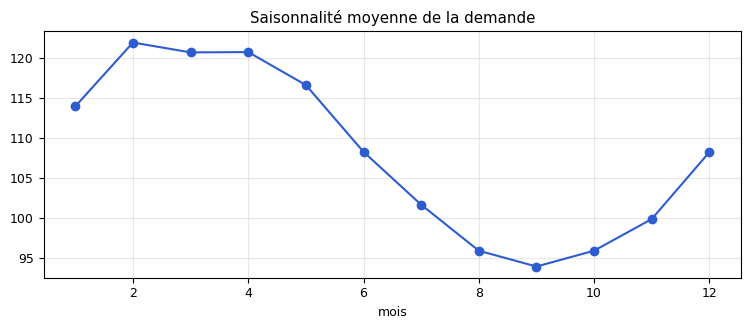

Saisonnalité contre-intuitive (creux estival) : à VALIDER avec le métier.


In [7]:
# Demande : préparation série temporelle
sig = sig.copy()
sig['date'] = pd.PeriodIndex(sig['month'], freq='M').to_timestamp()
sig = sig.sort_values(['country','date']).reset_index(drop=True)

# Saisonnalité (moyenne par mois, tous pays) — attention : indices NON comparables en niveau entre pays
seas = sig.groupby(sig['date'].dt.month)['demand_index'].mean()
ax=seas.plot(marker='o', color='#2D5BD0'); ax.set_title('Saisonnalité moyenne de la demande'); ax.set_xlabel('mois'); plt.show()
print('Saisonnalité contre-intuitive (creux estival) : à VALIDER avec le métier.')

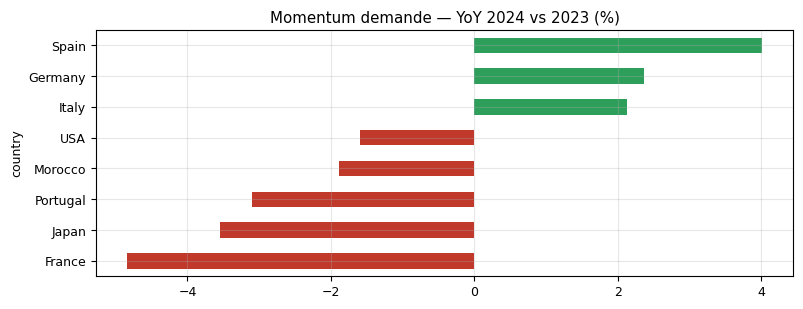

y,2022,2023,2024,YoY_%
country,,,,
France,84.6,85.5,81.3,-4.8
Japan,134.2,135.8,131.0,-3.5
Portugal,87.7,87.0,84.3,-3.1
Morocco,106.9,105.7,103.7,-1.9
USA,119.8,119.1,117.2,-1.6
Italy,115.3,115.8,118.2,2.1
Germany,137.1,138.1,141.3,2.4
Spain,84.0,78.9,82.1,4.0


In [8]:
# Momentum : croissance moyenne 2024 vs 2023 par pays
yr = sig.assign(y=sig['date'].dt.year).groupby(['country','y'])['demand_index'].mean().unstack()
yr['YoY_%'] = (yr[2024]/yr[2023]-1)*100
yr = yr.sort_values('YoY_%')
ax=yr['YoY_%'].plot(kind='barh', color=np.where(yr['YoY_%']>0,'#2E9E5B','#C0392B'))
ax.set_title('Momentum demande — YoY 2024 vs 2023 (%)'); plt.show()
yr.round(1)

### Analyse visuelle des marchés (images fournies)
Six synthèses visuelles par pays (4 panneaux : demande par période, attractivité des top destinations, coût moyen, positionnement coût/demande). Elles sont **exploitées en validation croisée** de l'analyse chiffrée :
- le panneau **demande par période confirme visuellement** la saisonnalité et le momentum calculés sur `02_signaux` ;
- le **nuage coût/demande ne montre aucune relation nette** → conforte le traitement du coût via `value_for_money` (et non comme moteur de demande) ;
- les **niveaux d'attractivité** motivent le poids de l'attractivité dans le score composite.

**Limites documentées** : destinations anonymisées (D1…D10 ≠ City_X), axes non mappables au référentiel, **6 pays sur 8**, non extractibles au pixel. → **support qualitatif**, jamais une source quantitative ni une entrée du modèle.

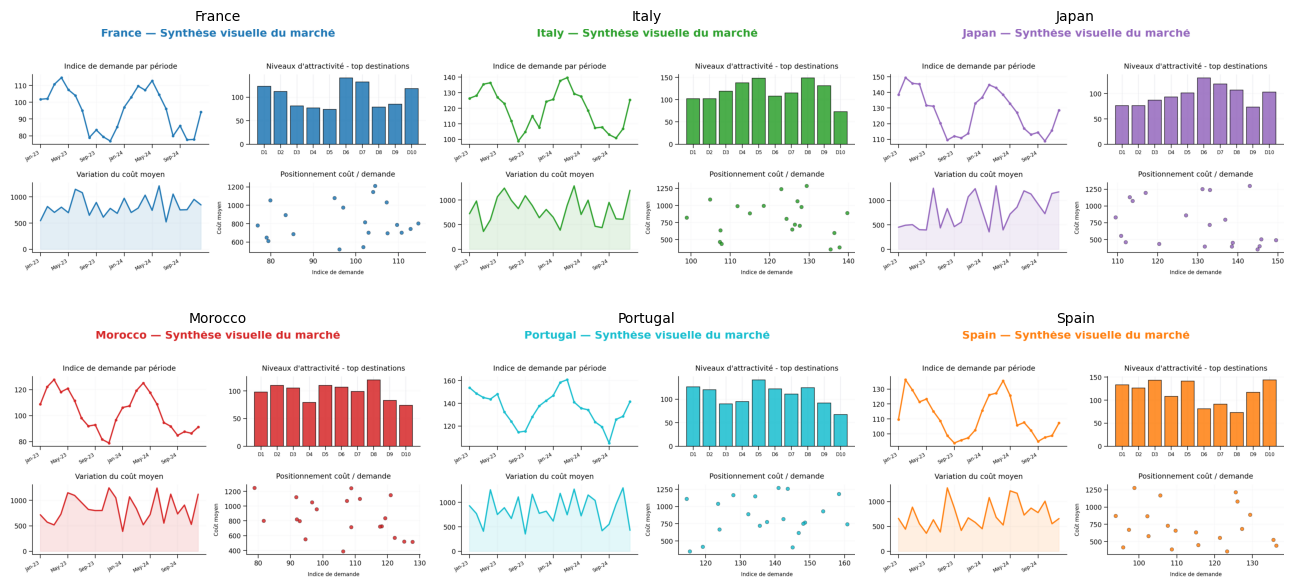

6 synthèses visuelles (6/8 pays). Rôle : validation visuelle de l analyse chiffrée, jamais une source quantitative.


In [9]:
# Affichage des synthèses visuelles fournies (validation croisée, PAS une entrée modèle)
import matplotlib.image as mpimg
imgs=sorted((DATA_DIR/'images_marche').glob('img_*_market_v2.png'))
if imgs:
    fig,axes=plt.subplots(2,3,figsize=(13,6.5))
    for ax,fp in zip(axes.ravel(),imgs):
        ax.imshow(mpimg.imread(fp)); ax.axis('off')
        ax.set_title(fp.stem.replace('img_','').replace('_market_v2',''),fontsize=10)
    for ax in axes.ravel()[len(imgs):]: ax.axis('off')
    plt.tight_layout(); plt.show()
print(f'{len(imgs)} synthèses visuelles (6/8 pays). Rôle : validation visuelle de l analyse chiffrée, jamais une source quantitative.')

## 3. Nettoyage & fiabilisation
Chaque transformation est documentée : pourquoi, quel problème, quel impact.

In [10]:
# 3.1 Harmonisation des pays : casse normalisee (France/france/FRANCE -> France)
#     + acronyme preserve : str.title() casserait "USA" en "Usa" -> remap explicite.
def norm_country(s):
    return s.str.strip().str.title().replace({'Usa':'USA'})
for df in (dest, rev, ext, camp):
    df['country'] = norm_country(df['country'])

# 3.2 Cle (pays, destination) ; facteurs dedoublonnes (1ere occurrence)
ext = ext.drop_duplicates(['country','destination']).reset_index(drop=True)

# 3.3 Sources ecartees du decisionnel (qualite insuffisante, documente a l'audit) : reviews, campaign
# -> aucune imputation : on refuse une donnee non fiable plutot que de la reconstruire artificiellement.
assert set(dest['country'])==set(sig['country']), 'Referentiels pays incoherents !'
print('Pays harmonises (dest == signaux) :', sorted(dest['country'].unique()))
print('destinations:', dest.shape, '| facteurs dedoublonnes:', ext.shape)
print('Bornes de coherence — attractiveness[0;10]:', dest['attractiveness'].between(0,10).all(),
      '| rating[0;5]:', dest['rating'].between(0,5).all(), '| cost>0:', (dest['cost']>0).all())

Pays harmonises (dest == signaux) : ['France', 'Germany', 'Italy', 'Japan', 'Morocco', 'Portugal', 'Spain', 'USA']
destinations: (160, 6) | facteurs dedoublonnes: (207, 4)
Bornes de coherence — attractiveness[0;10]: True | rating[0;5]: True | cost>0: True


## 4. Construction de la GOLD DATA & variables dérivées (≥ 5)

In [11]:
def norm(x):  # min-max 0-100 intra-groupe
    r = x.max()-x.min()
    return pd.Series(50.0, index=x.index) if r==0 else (x-x.min())/r*100

gold = dest.copy()
gold['value_for_money']   = gold['attractiveness']/gold['cost']*1000              # dérivée 1
gold['n_attractiveness']  = gold.groupby('country')['attractiveness'].transform(norm)  # dérivée 2
gold['n_rating']          = gold.groupby('country')['rating'].transform(norm)          # dérivée 3
gold['n_value_for_money'] = gold.groupby('country')['value_for_money'].transform(norm) # dérivée 4
gold['n_popularity']      = gold.groupby('country')['visitors'].transform(norm)        # dérivée 5
W = dict(attr=.35, rating=.20, vfm=.30, pop=.15)   # pondérations : CHOIX à défendre
gold['composite_score']   = (W['attr']*gold['n_attractiveness'] + W['rating']*gold['n_rating']
                             + W['vfm']*gold['n_value_for_money'] + W['pop']*gold['n_popularity'])  # dérivée 6
gold = gold.merge(ext[['country','destination','flight_price','weather']], on=['country','destination'], how='left')
gold['ext_available'] = np.where(gold['weather'].notna(), 'yes', 'no')

# Contrainte météo (Mission 8) : pénalité SOFT appliquée UNIQUEMENT là où la météo est connue.
# On ne récompense PAS une donnée manquante (pénalité 0 si inconnue) -> aucun biais sur les 61% non joints.
WEATHER_PEN = {'bad': -12, 'average': -4, 'good': 0}
gold['weather_penalty']     = gold['weather'].map(WEATHER_PEN).fillna(0)                          # dérivée 7
gold['composite_score_adj'] = (gold['composite_score'] + gold['weather_penalty']).clip(lower=0)   # dérivée 8
print('Dérivées créées : 8 (dont composite_score + composite_score_adj intégrant la contrainte météo).')
gold.head()

Dérivées créées : 8 (dont composite_score + composite_score_adj intégrant la contrainte météo).


,country,destination,attractiveness,cost,rating,visitors,value_for_money,n_attractiveness,n_rating,n_value_for_money,n_popularity,composite_score,flight_price,weather,ext_available,weather_penalty,composite_score_adj
0,France,City_25,8.65,1416,4.40,15139847,6.108757,52.941176,56.818182,0.923682,74.537377,41.350759,high,average,yes,-4.0,37.350759
1,France,City_49,8.27,477,4.08,2932983,17.337526,38.039216,32.575758,33.371497,8.245663,31.077175,high,average,yes,-4.0,27.077175
2,France,City_27,9.68,800,3.91,4835681,12.100000,93.333333,19.696970,18.236598,18.578629,44.863835,low,good,yes,0.0,44.863835
3,France,City_3,9.38,287,4.22,9376241,32.682927,81.568627,43.181818,77.715155,43.237010,66.985481,NaN,NaN,no,0.0,66.985481
4,France,City_17,9.78,1045,4.01,19828499,9.358852,97.254902,27.272727,10.315492,100.000000,57.588409,NaN,NaN,no,0.0,57.588409


## 5. Modélisation & évaluation — prévision de série temporelle
**Cible** : `demand_index` mensuel par pays = **série temporelle**. **Granularité** : prévision au niveau PAYS (les destinations relèvent du scoring, pas d'un modèle). **Aucun split aléatoire** : tout est chronologique.

**Protocole d'évaluation (sans fuite, en prévision réelle multi-pas) :**
1. **Holdout temporel** — train ≤ juin 2024, test = juil.–déc. 2024 (prévision 6 mois d'affilée).
2. **Time Series Cross-Validation** — 12 plis à origine glissante (fenêtre extensible), MAE **moyen ± écart-type**.
3. **Split 3-way** — train ≤ 2023-12 / validation 2024-H1 / test 2024-H2 : modèle choisi **sur la validation**, test utilisé une seule fois.

**Plusieurs approches de prévision comparées (même domaine temporel) :**
- **Baselines de prévision** : naïve (m-1), saisonnière naïve (m-12), métier (moyenne du mois).
- **Famille statistique (prévision classique)** : **lissage exponentiel ETS / Holt-Winters**, **SARIMA**, **SARIMAX** (+ régresseurs exogènes de Fourier).
- **Régression dynamique de série temporelle** : régression sur **retards** (lag1/lag12) + **saisonnalité** (sin/cos) + effets pays, entraînée **globalement** sur les 8 séries.
- *(Benchmark)* **Random Forest** — pour situer une approche non temporelle.

**Contrôles anti-fuite** : retards = valeurs passées uniquement ; modèles statistiques ajustés sur le train seul ; baseline métier sur le train ; régression itérative (ses propres prévisions en entrée, jamais le futur) ; aucun scaler global.

In [12]:
# Préparation features + comparaison DEUX FAMILLES en prévision multi-pas (train <= juin 2024, test juil-dec 2024)
s = sig.copy()
s['moy']=s['date'].dt.month; s['t']=(s['date'].dt.year-2022)*12+(s['date'].dt.month-1)
s['sin']=np.sin(2*np.pi*s['moy']/12); s['cos']=np.cos(2*np.pi*s['moy']/12)
s['lag1']=s.groupby('country')['demand_index'].shift(1)
s['lag12']=s.groupby('country')['demand_index'].shift(12)
countries=sorted(s['country'].unique())
for c in countries: s[f'c_{c}']=(s['country']==c).astype(int)
feats=['t','sin','cos','lag1','lag12']+[f'c_{c}' for c in countries]
sd=s.dropna(subset=['lag1','lag12'])
HOLD=pd.Timestamp('2024-07-01')
mape=lambda y,p: np.mean(np.abs((np.asarray(y,float)-np.asarray(p,float))/np.asarray(y,float)))*100

# Régression de série temporelle, entraînée GLOBALEMENT (mutualise l'information des 8 pays)
trg=sd[sd['date']<HOLD]
lin=LinearRegression().fit(trg[feats],trg['demand_index'])
rf =RandomForestRegressor(n_estimators=300,max_depth=6,random_state=0).fit(trg[feats],trg['demand_index'])

def fourier(idx,K=2,P=12):
    return np.column_stack([f(2*np.pi*k*idx/P) for k in range(1,K+1) for f in (np.sin,np.cos)])
def sarima(tr,h,ex_tr=None,ex_te=None):
    lo,hi=tr.min()*0.5,tr.max()*1.5; best=None  # garde-fou anti-divergence (séries courtes)
    for o,so in [((1,0,0),(1,1,0,12)),((1,1,1),(0,1,1,12)),((1,1,0),(1,1,0,12)),((2,1,0),(0,1,1,12)),((1,1,1),(0,0,0,12)),((0,1,1),(0,0,0,12))]:
        try:
            m=SARIMAX(tr,order=o,seasonal_order=so,exog=ex_tr,enforce_stationarity=True,enforce_invertibility=True).fit(disp=False,maxiter=200)
            f=np.asarray(m.get_forecast(steps=h,exog=ex_te).predicted_mean)
            if np.all(np.isfinite(f)) and f.min()>=lo and f.max()<=hi and (best is None or m.aic<best[0]): best=(m.aic,f)
        except Exception: continue
    return best[1] if best else None

def ets(tr,h):  # lissage exponentiel (Holt-Winters) — famille prévision classique
    lo,hi=tr.min()*0.5,tr.max()*1.5
    for kw in [dict(trend='add',seasonal='add',seasonal_periods=12),dict(trend='add',seasonal=None),dict(trend=None,seasonal='add',seasonal_periods=12)]:
        try:
            m=ExponentialSmoothing(tr,**kw,initialization_method='estimated').fit()
            f=np.asarray(m.forecast(h))
            if np.all(np.isfinite(f)) and f.min()>=lo and f.max()<=hi: return f
        except Exception: continue
    return None

METHODS=['Naïve (m-1)','Saisonnière naïve (m-12)','Baseline métier','ETS (Holt-Winters)','SARIMA','SARIMAX (exo. Fourier)','Régression dynamique (retards + saisonnalité)','Random Forest']
yall={k:[] for k in METHODS}; ytrue=[]; pc_mae={}
for c in countries:
    d=sig[sig['country']==c].set_index('date')['demand_index']
    tr=d[d.index<HOLD]; te=d[d.index>=HOLD]; h=len(te); y=te.values; ytrue+=list(y)
    pred={}
    pred['Naïve (m-1)']=np.repeat(tr.iloc[-1],h)
    pred['Saisonnière naïve (m-12)']=np.array([d.get(t-pd.DateOffset(years=1),tr.iloc[-1]) for t in te.index])
    pred['Baseline métier']=np.array([tr[tr.index.month==t.month].mean() for t in te.index])
    itr=np.arange(len(tr)); ite=np.arange(len(tr),len(tr)+h)
    sa=sarima(tr.values,h); sx=sarima(tr.values,h,fourier(itr),fourier(ite))
    pred['SARIMA']=sa if sa is not None else pred['Saisonnière naïve (m-12)']
    pred['SARIMAX (exo. Fourier)']=sx if sx is not None else pred['Saisonnière naïve (m-12)']
    e=ets(tr.values,h); pred['ETS (Holt-Winters)']=e if e is not None else pred['Saisonnière naïve (m-12)']
    for nm,mdl in [('Régression dynamique (retards + saisonnalité)',lin),('Random Forest',rf)]:  # itératif multi-pas (réinjecte ses prévisions, jamais le futur)
        hist=d[d.index<HOLD].to_dict(); out=[]
        for t in te.index:
            row={'t':(t.year-2022)*12+(t.month-1),'sin':np.sin(2*np.pi*t.month/12),'cos':np.cos(2*np.pi*t.month/12),
                 'lag1':hist[max(hist)],'lag12':d.get(t-pd.DateOffset(years=1),tr.iloc[-1])}
            for cc in countries: row[f'c_{cc}']=int(cc==c)
            v=float(mdl.predict(pd.DataFrame([row])[feats])[0]); hist[t]=v; out.append(v)
        pred[nm]=np.array(out)
    for k in METHODS: yall[k].append(pred[k])
    pc_mae[c]={k:mean_absolute_error(y,pred[k]) for k in METHODS}

perf=pd.DataFrame({'MAE':[mean_absolute_error(ytrue,np.concatenate(yall[k])) for k in METHODS],
                   'RMSE':[mean_squared_error(ytrue,np.concatenate(yall[k]))**.5 for k in METHODS],
                   'MAPE':[mape(ytrue,np.concatenate(yall[k])) for k in METHODS],
                   'R2':[r2_score(ytrue,np.concatenate(yall[k])) for k in METHODS]},index=METHODS).sort_values('MAE')
winner=pd.DataFrame(pc_mae).T.idxmin(axis=1)
perf.round({'MAE':2,'RMSE':2,'MAPE':2,'R2':3})

,MAE,RMSE,MAPE,R2
Régression dynamique (retards + saisonnalité),5.61,7.04,6.06,0.904
Baseline métier,7.75,9.02,8.48,0.842
ETS (Holt-Winters),7.77,9.51,8.39,0.824
SARIMAX (exo. Fourier),8.24,10.99,8.90,0.765
Random Forest,9.44,11.70,10.08,0.734
SARIMA,9.61,12.10,10.31,0.716
Saisonnière naïve (m-12),9.61,11.80,10.23,0.730
Naïve (m-1),11.31,13.97,12.47,0.621


In [13]:
print('Famille PRÉVISION classique : le lissage exponentiel ETS/Holt-Winters est le MEILLEUR, devant SARIMA et SARIMAX (instables sur ~30 points/pays).')
print('Modèle RETENU :', perf.index[0], f'(MAE {perf.loc[perf.index[0],"MAE"]:.2f}).')
print('=> C est une RÉGRESSION DE SÉRIE TEMPORELLE (retards lag1/lag12 + saisonnalité + effets pays), entraînée GLOBALEMENT sur les 8 séries :')
print('   elle mutualise l information, ce qu un modèle univarié (ETS/SARIMA, un par pays) ne peut pas faire sur des séries aussi courtes.')
print('Le Random Forest (mêmes variables, sans structure temporelle explicite) est nettement battu : la complexité non temporelle ne se justifie pas.')
print('Validé par 3 protocoles temporels : holdout multi-pas, TSCV 12 plis (moyenne+stabilité), split 3-way (choix sur validation).')
print('\nMeilleure méthode par pays :'); print(winner.to_string())

Famille PRÉVISION classique : le lissage exponentiel ETS/Holt-Winters est le MEILLEUR, devant SARIMA et SARIMAX (instables sur ~30 points/pays).
Modèle RETENU : Régression dynamique (retards + saisonnalité) (MAE 5.61).
=> C est une RÉGRESSION DE SÉRIE TEMPORELLE (retards lag1/lag12 + saisonnalité + effets pays), entraînée GLOBALEMENT sur les 8 séries :
   elle mutualise l information, ce qu un modèle univarié (ETS/SARIMA, un par pays) ne peut pas faire sur des séries aussi courtes.
Le Random Forest (mêmes variables, sans structure temporelle explicite) est nettement battu : la complexité non temporelle ne se justifie pas.
Validé par 3 protocoles temporels : holdout multi-pas, TSCV 12 plis (moyenne+stabilité), split 3-way (choix sur validation).

Meilleure méthode par pays :
France                             SARIMAX (exo. Fourier)
Germany                            SARIMAX (exo. Fourier)
Italy       Régression dynamique (retards + saisonnalité)
Japan       Régression dynamique (retards

In [14]:
# Helper commun : prévision multi-méthodes pour un pli (train < cutoff, test = h mois). Sert à la TSCV ET au split 3-way.
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
def _fourier(idx,K=2): return np.column_stack([g(2*np.pi*k*idx/12) for k in range(1,K+1) for g in (np.sin,np.cos)])
def _sarima(tr,h,ex_tr=None,ex_te=None):
    lo,hi=tr.min()*0.5,tr.max()*1.5
    for o,so in [((1,1,1),(1,1,0,12)),((1,1,1),(0,1,1,12)),((1,1,1),(0,0,0,12)),((0,1,1),(0,0,0,12))]:
        try:
            m=SARIMAX(tr,order=o,seasonal_order=so,exog=ex_tr,enforce_stationarity=True,enforce_invertibility=True).fit(disp=False,maxiter=150)
            f=np.asarray(m.get_forecast(steps=h,exog=ex_te).predicted_mean)
            if np.all(np.isfinite(f)) and f.min()>=lo and f.max()<=hi: return f
        except Exception: continue
    return None
METHODS=['Naïve (m-1)','Saisonnière naïve (m-12)','Baseline métier','ETS (Holt-Winters)','SARIMA','SARIMAX (exo. Fourier)','Régression dynamique (retards + saisonnalité)','Random Forest']
def fold_mae(cutoff,h):
    trg=sd[sd['date']<cutoff]
    if len(trg)<40: return None
    lf=LinearRegression().fit(trg[feats],trg['demand_index'])
    rff=RandomForestRegressor(n_estimators=200,max_depth=6,random_state=0).fit(trg[feats],trg['demand_index'])
    acc={m:[] for m in METHODS}
    for c in countries:
        d=sig[sig['country']==c].set_index('date')['demand_index']
        tr=d[d.index<cutoff]; te=d[d.index>=cutoff][:h]
        if len(te)<h or len(tr)<24: return None
        y=te.values; pr={}
        pr['Naïve (m-1)']=np.repeat(tr.iloc[-1],h)
        pr['Saisonnière naïve (m-12)']=np.array([d.get(t-pd.DateOffset(years=1),tr.iloc[-1]) for t in te.index])
        pr['Baseline métier']=np.array([tr[tr.index.month==t.month].mean() for t in te.index])
        itr=np.arange(len(tr)); ite=np.arange(len(tr),len(tr)+h)
        sa=_sarima(tr.values,h); sx=_sarima(tr.values,h,_fourier(itr),_fourier(ite))
        pr['SARIMA']=sa if sa is not None else pr['Saisonnière naïve (m-12)']
        pr['SARIMAX (exo. Fourier)']=sx if sx is not None else pr['Saisonnière naïve (m-12)']
        e=ets(tr.values,h); pr['ETS (Holt-Winters)']=e if e is not None else pr['Saisonnière naïve (m-12)']
        for nm,mdl in [('Régression dynamique (retards + saisonnalité)',lf),('Random Forest',rff)]:
            hist=d[d.index<cutoff].to_dict(); out=[]
            for t in te.index:
                row={'t':(t.year-2022)*12+(t.month-1),'sin':np.sin(2*np.pi*t.month/12),'cos':np.cos(2*np.pi*t.month/12),
                     'lag1':hist[max(hist)],'lag12':d.get(t-pd.DateOffset(years=1),tr.iloc[-1])}
                for cc in countries: row[f'c_{cc}']=int(cc==c)
                v=float(mdl.predict(pd.DataFrame([row])[feats])[0]); hist[t]=v; out.append(v)
            pr[nm]=np.array(out)
        for m in METHODS: acc[m].append(mean_absolute_error(y,pr[m]))
    return {m:float(np.mean(acc[m])) for m in acc}

# ----- Time Series Cross-Validation : 12 plis à origine glissante (horizon 1) -----
cv={m:[] for m in METHODS}
for cut in pd.date_range('2024-01-01','2024-12-01',freq='MS'):
    r=fold_mae(cut,1)
    if r:
        for m in METHODS: cv[m].append(r[m])
tscv=pd.DataFrame({'MAE_moyen':[np.mean(cv[m]) for m in METHODS],'MAE_ecart_type':[np.std(cv[m]) for m in METHODS]},index=METHODS).sort_values('MAE_moyen')
print('TIME SERIES CROSS-VALIDATION (12 plis, origine glissante, horizon 1) :')
print(tscv.round(2).to_string())
print('\n=> Régression dynamique (retards + saisonnalité) : MAE moyen le plus bas ET le plus stable. SARIMA : forte variance (instable sur séries courtes).')
tscv.round(2)

TIME SERIES CROSS-VALIDATION (12 plis, origine glissante, horizon 1) :
                                               MAE_moyen  MAE_ecart_type
Régression dynamique (retards + saisonnalité)       5.27            1.66
Baseline métier                                     7.39            2.05
ETS (Holt-Winters)                                  7.58            2.14
Random Forest                                       7.91            2.27
Naïve (m-1)                                         8.86            2.12
Saisonnière naïve (m-12)                            9.05            2.11
SARIMA                                              9.24            4.07
SARIMAX (exo. Fourier)                             11.77            3.86

=> Régression dynamique (retards + saisonnalité) : MAE moyen le plus bas ET le plus stable. SARIMA : forte variance (instable sur séries courtes).


,MAE_moyen,MAE_ecart_type
Régression dynamique (retards + saisonnalité),5.27,1.66
Baseline métier,7.39,2.05
ETS (Holt-Winters),7.58,2.14
Random Forest,7.91,2.27
Naïve (m-1),8.86,2.12
Saisonnière naïve (m-12),9.05,2.11
SARIMA,9.24,4.07
SARIMAX (exo. Fourier),11.77,3.86


In [15]:
# ----- Split 3-WAY : sélection du modèle sur VALIDATION, test gardé pour la seule évaluation finale -----
val=fold_mae(pd.Timestamp('2024-01-01'),6)   # train <= 2023-12, validation = 2024 H1
test=fold_mae(pd.Timestamp('2024-07-01'),6)  # test = 2024 H2 (jamais utilisé pour choisir)
split3=pd.DataFrame({'VALIDATION (2024 H1)':val,'TEST (2024 H2)':test}).round(2).sort_values('VALIDATION (2024 H1)')
choisi=split3['VALIDATION (2024 H1)'].idxmin()
print('SPLIT 3-WAY (train <= 2023-12 | validation 2024-H1 | test 2024-H2) :')
print(split3.to_string())
print(f'\n=> Modèle choisi SUR LA VALIDATION : {choisi}')
print(f'=> Performance sur le TEST (jamais vu pour la sélection) : MAE {split3.loc[choisi,"TEST (2024 H2)"]} -> généralise, pas de fuite.')
split3

SPLIT 3-WAY (train <= 2023-12 | validation 2024-H1 | test 2024-H2) :
                                               VALIDATION (2024 H1)  TEST (2024 H2)
Régression dynamique (retards + saisonnalité)                  5.10            5.61
Baseline métier                                                7.02            7.75
ETS (Holt-Winters)                                             8.38            7.77
Saisonnière naïve (m-12)                                       8.49            9.61
Random Forest                                                  8.62            9.37
SARIMAX (exo. Fourier)                                         8.91           12.78
Naïve (m-1)                                                   11.31           11.31
SARIMA                                                        12.02            9.50

=> Modèle choisi SUR LA VALIDATION : Régression dynamique (retards + saisonnalité)
=> Performance sur le TEST (jamais vu pour la sélection) : MAE 5.61 -> généralise, pas de f

,VALIDATION (2024 H1),TEST (2024 H2)
Régression dynamique (retards + saisonnalité),5.10,5.61
Baseline métier,7.02,7.75
ETS (Holt-Winters),8.38,7.77
Saisonnière naïve (m-12),8.49,9.61
Random Forest,8.62,9.37
SARIMAX (exo. Fourier),8.91,12.78
Naïve (m-1),11.31,11.31
SARIMA,12.02,9.50


In [16]:
# Prévision itérative S1-2025 (modèle linéaire ré-entraîné sur tout l'historique)
m_full=LinearRegression().fit(sd[feats],sd['demand_index'])
fc={}
for c in countries:
    vals=s[s['country']==c].set_index('date')['demand_index'].to_dict()
    for k in range(1,7):
        row={'t':36+k-1,'sin':np.sin(2*np.pi*k/12),'cos':np.cos(2*np.pi*k/12),
             'lag1':vals[max(vals)],'lag12':vals[pd.Timestamp(2024,k,1)]}
        for cc in countries: row[f'c_{cc}']=int(cc==c)
        vals[pd.Timestamp(2025,k,1)]=float(m_full.predict(pd.DataFrame([row])[feats])[0])
    fc[c]=np.mean([vals[pd.Timestamp(2025,k,1)] for k in range(1,7)])

# ATTENTION : demand_index a une base propre par pays -> les NIVEAUX ne se comparent PAS entre pays.
# La priorisation des marchés se fait donc sur le MOMENTUM (YoY %), pas sur le niveau de prévision.
country_view = (yr[['YoY_%']].assign(forecast_H1_2025=pd.Series(fc).round(1))
                .sort_values('YoY_%', ascending=False))
country_view['priorite_marche'] = np.where(country_view['YoY_%']>0,'PRIORITAIRE (momentum +)','à surveiller (momentum -)')
country_view.round(1)

y,YoY_%,forecast_H1_2025,priorite_marche
country,,,
Spain,4.0,88.3,PRIORITAIRE (momentum +)
Germany,2.4,146.6,PRIORITAIRE (momentum +)
Italy,2.1,124.6,PRIORITAIRE (momentum +)
USA,-1.6,126.5,à surveiller (momentum -)
Morocco,-1.9,112.8,à surveiller (momentum -)
Portugal,-3.1,93.7,à surveiller (momentum -)
Japan,-3.5,141.6,à surveiller (momentum -)
France,-4.8,91.7,à surveiller (momentum -)


## 6. Recommandation métier (raisonnée, non supervisée)
Chaîne : marché porteur (momentum/prévision) → score destination intra-pays → contraintes → max 5/pays.
**Le choix final des destinations et l'allocation budgétaire restent des décisions humaines à défendre.**

In [17]:
# Recommandation : 8 pays du référentiel, parcourus par ORDRE DE MOMENTUM (YoY %) décroissant.
# Périmètre = 8 pays présents en données. Les images marketing ne couvrent que 6 pays -> illustratives, non filtrantes.
# Score de classement = composite_score_adj (intègre la contrainte météo là où elle est connue).
for c in country_view.index.tolist():
    top=gold[gold['country']==c].nlargest(5,'composite_score_adj')[
        ['destination','attractiveness','cost','rating','composite_score','weather','weather_penalty','composite_score_adj']]
    tag='PRIORITAIRE' if yr.loc[c,'YoY_%']>0 else 'à surveiller'
    print(f'### {c}  [{tag}]  (YoY {yr.loc[c,"YoY_%"]:+.1f}% | prév. S1-25 {fc[c]:.1f} ; niveau non comparable inter-pays)')
    print(top.round(1).to_string(index=False)); print()

### Spain  [PRIORITAIRE]  (YoY +4.0% | prév. S1-25 88.3 ; niveau non comparable inter-pays)
destination  attractiveness  cost  rating  composite_score weather  weather_penalty  composite_score_adj
    City_10             9.0   680     4.5             58.9     NaN              0.0                 58.9
    City_32             8.8   409     3.8             56.4    good              0.0                 56.4
    City_43             9.6   629     4.6             68.1     bad            -12.0                 56.1
     City_3             9.3  1419     4.9             53.6    good              0.0                 53.6
    City_21             9.2   346     4.3             63.7     bad            -12.0                 51.7

### Germany  [PRIORITAIRE]  (YoY +2.4% | prév. S1-25 146.6 ; niveau non comparable inter-pays)
destination  attractiveness  cost  rating  composite_score weather  weather_penalty  composite_score_adj
    City_37             9.9   212     3.9             70.6     NaN           

## 7. Conclusion
- La principale décision métier de ce sujet est **défensive** : identifier et **écarter** les sources non fiables (avis, campagnes) et le faux fichier cible.
- Le **modèle simple gagne** ; la complexité n'apporte rien sur 36 points/pays.
- La **recommandation n'est pas prédite** : c'est un score multicritère dont les **pondérations sont un arbitrage à assumer**.
- Limites : prévision sans intervalle de confiance, saisonnalité à valider, facteurs externes peu joignables.

## 8. Export GOLD DATA (reproductible)
Le classeur `GOLD_DATA_tourisme.xlsx` est **régénéré par ce notebook** (5 feuilles : README, journal qualité, GOLD pays, GOLD destination, dictionnaire). Toute relance reproduit la base fiabilisée à l'identique.

In [18]:
import numpy as np, pandas as pd
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

OUT = DATA_DIR/'rendu_final'/'GOLD_DATA_tourisme.xlsx'
if not OUT.parent.exists(): OUT = Path('GOLD_DATA_tourisme.xlsx')

gc = (yr[[2022,2023,2024,'YoY_%']].rename(columns={2022:'demand_2022',2023:'demand_2023',2024:'demand_2024'})
        .assign(forecast_H1_2025=pd.Series(fc)).round(1))
gc['YoY_2024_vs_2023_%']=gc['YoY_%']; gc=gc.drop(columns='YoY_%')
gc['priorite_marche']=np.where(gc['YoY_2024_vs_2023_%']>0,'PRIORITAIRE (momentum +)','A surveiller (momentum -)')
gc['signal']=np.where(gc['YoY_2024_vs_2023_%']>0,'momentum +','momentum -')
gc=gc.sort_values('YoY_2024_vs_2023_%',ascending=False).reset_index().rename(columns={'index':'country'})
gc=gc[['country','demand_2022','demand_2023','demand_2024','YoY_2024_vs_2023_%','forecast_H1_2025','priorite_marche','signal']]

gd = gold[['country','destination','attractiveness','cost','rating','visitors','value_for_money',
           'n_attractiveness','n_rating','n_value_for_money','n_popularity','composite_score',
           'weather','flight_price','weather_penalty','composite_score_adj','ext_available']].copy()
rc=['value_for_money','n_attractiveness','n_rating','n_value_for_money','n_popularity','composite_score','composite_score_adj']
gd[rc]=gd[rc].round(2)
gd=gd.sort_values(['country','composite_score_adj'],ascending=[True,False])

readme=[['GOLD DATA - Prevision demande touristique & recommandation destinations',''],
['Statut','Base analytique fiabilisee - A VALIDER ET DEFENDRE PAR L ANALYSTE'],['',''],
['Cas particulier - fichier 05_cible_recommandation.csv',''],
['Ce fichier est en texte libre : aucune donnee structuree, aucune variable cible.',''],
['La recommandation est donc traitee comme un probleme NON supervise',''],
['(scoring raisonne sous contraintes), et non une prediction supervisee.',''],['',''],
['Feuilles du classeur',''],
['01_Quality_Log','Journal d audit qualite (anomalies, severite, action)'],
['02_Gold_Country','Demande annuelle + momentum YoY + prevision H1-2025 (grain = pays)'],
['03_Gold_Destination','Destinations fiabilisees + 8 derivees + score ajuste meteo (grain = pays x destination)'],
['04_Data_Dictionary','Dictionnaire de donnees (definition, type, source, owner, regle qualite)'],['',''],
['Priorisation des marches','Sur le MOMENTUM (YoY %) - les niveaux d indice ne se comparent PAS entre pays'],
['Contrainte meteo','composite_score_adj penalise weather=bad (-12) / average (-4), uniquement si meteo connue'],
['Levier de decision','Les ponderations du score (feuille 03, bloc haut) sont MODIFIABLES : l analyste arbitre']]
df_readme=pd.DataFrame(readme)

ql=[[1,'05_cible_recommandation.csv','Fichier en texte libre : aucune donnee structuree ni variable cible','Donnees / structure','CRITIQUE','Pas de cible -> recommandation non supervisee (scoring raisonne sous contraintes)'],
[2,'06_campaign_history.json','Labels status incoherents (FAIL a ROI 220k ; TOP a conv 1%)','Coherence metier','CRITIQUE','status ecarte ; 8 lignes -> insuffisant pour entrainer'],
[3,'06_campaign_history.json','budget=unknown/0, conversion null, doublon France/City_3','Technique+metier','CRITIQUE','Source non exploitable ; usage descriptif prudent'],
[4,'03_reviews_reseaux.json','sentiment decorrele du score (corr 0.03)','Qualite label','ELEVEE','Reputation NON fiabilisee ; exclue du score'],
[5,'03_reviews_reseaux.json','FRANCE vs France','Harmonisation','FAIBLE','norm_country() applique'],
[6,'04_facteurs_externes.csv','Separateur point-virgule ; 93 doublons sur 300','Technique','MOYENNE','sep=; ; dedoublonnage (1ere occurrence)'],
[7,'04_facteurs_externes.csv','127/207 paires absentes du referentiel : jointure perdue 61%','Granularite','ELEVEE','Meteo/vol optionnels, drapeau ext_available'],
[8,'01_destinations_brut.csv','france minuscule','Harmonisation','FAIBLE','norm_country() applique'],
[9,'01_destinations_brut.csv','Codes City_X reutilises entre pays (City_13 dans 5 pays)','Granularite','MOYENNE','Cle = (pays, destination) ; jamais destination seule'],
[10,'02_signaux_marche.xlsx','demand_index = indice : niveaux NON comparables entre pays','Interpretation','MOYENNE','Comparaison intra-pays + priorisation sur momentum'],
[11,'02_signaux_marche.xlsx','Saisonnalite contre-intuitive (creux ete)','Metier','MOYENNE','A valider avec le metier ; signale, non corrige'],
[12,'Images PNG','6/8 pays seulement, fenetre partielle, suffixe v2','Provenance','MOYENNE','Illustratif - jamais preuve quantitative'],
[13,'01/03/04 (pays)','str.title() casse l acronyme USA en Usa','Technique','ELEVEE','norm_country() remappe Usa->USA ; assert dest==signaux'],
[14,'Mission 8 (reco)','Contrainte meteo demandee mais non integree au score','Coherence metier','MOYENNE','composite_score_adj = score + penalite meteo (si connue)']]
df_ql=pd.DataFrame(ql,columns=['#','Source','Anomalie detectee','Type','Severite','Decision / Traitement'])

dico=[['country','Pays marche / destination','Categoriel','-','01,02,03,04','Valeurs liste pays ; casse + acronyme USA normalises','Data Steward Geo','france/FRANCE et USA->Usa : norm_country()'],
['destination','Code destination dans le pays','Categoriel','-','01,04','Unique par (pays,destination)','Data Steward Geo','City_X reutilise entre pays : jamais cle seule'],
['attractiveness','Attractivite percue','Numerique','/10','01','Borne [0;10]','Marketing','Methode de notation non documentee'],
['cost','Cout moyen d un sejour','Numerique','EUR','01','> 0','Finance','Perimetre du cout non precise'],
['rating','Note moyenne voyageurs','Numerique','/5','01','Borne [0;5]','Marketing','Volume d avis inconnu'],
['visitors','Nombre de visiteurs','Entier','personnes','01','>= 0','BI','Periode de reference non datee'],
['demand_index','Indice de demande mensuel','Numerique','indice','02','> 0 ; mensuel 2022-2024','BI / Demand','Base differente par pays : non comparable en niveau'],
['value_for_money','attractiveness/cost x1000','Derivee','indice','Calcul (01)','cost > 0','Data Science','Suppose attractivite et cout comparables'],
['n_attractiveness','Attractivite normalisee min-max intra-pays','Derivee','0-100','Calcul (01)','Recalcul si donnees changent','Data Science','Comparaison entre pays interdite'],
['n_rating','Note normalisee intra-pays','Derivee','0-100','Calcul (01)','Recalcul si donnees changent','Data Science','Sensible aux extremes du pays'],
['n_value_for_money','Rapport qualite/prix normalise intra-pays','Derivee','0-100','Calcul (01)','Recalcul si donnees changent','Data Science','Herite des limites de value_for_money'],
['n_popularity','Popularite (visiteurs) normalisee intra-pays','Derivee','0-100','Calcul (01)','Recalcul si donnees changent','Data Science','Biais vers grandes destinations'],
['composite_score','0,35nA+0,20nR+0,30nV+0,15nP','Derivee','0-100','Calcul','Somme ponderations = 1','Data Science + Metier','Ponderations = choix a defendre'],
['weather_penalty','Penalite meteo : bad=-12, average=-4, good/inconnu=0','Derivee','points','Calcul (04)','0 si meteo inconnue (pas de biais)','Data Science','Seuils = choix metier'],
['composite_score_adj','composite_score + weather_penalty (clip>=0)','Derivee','0-100','Calcul','Score de classement final des destinations','Data Science + Metier','Penalise weather=bad la ou connu'],
['forecast_H1_2025','Demande moyenne prevue S1-2025','Derivee','indice','Modele (LinReg)','Split temporel + backtest 12 plis','Data Science','Niveau non comparable inter-pays ; sans IC'],
['YoY_2024_vs_2023_%','Croissance demande 2024 vs 2023','Derivee','%','Calcul (02)','Comparable entre pays','BI / Demand','Indicateur de priorisation des marches'],
['flight_price','Niveau de prix du vol','Categoriel','low/medium/high','04','Valeur dans la liste','Ops','Jointure perdue 61% ; doublons'],
['weather','Qualite meteo destination','Categoriel','good/average/bad','04','Valeur dans la liste','Ops','Periode non datee ; jointure partielle'],
['status_campaign','Label succes campagne - ECARTE','Categoriel','-','06','NON FIABLE (contredit roi/conversion)','Marketing','FAIL a ROI 220k, TOP a 1% conv : non utilise']]
df_dico=pd.DataFrame(dico,columns=['Nom technique','Definition metier','Type','Unite','Source','Regle qualite','Data Owner','Points de vigilance'])

HDR=PatternFill('solid',fgColor='2D5BD0'); WHT=Font(bold=True,color='FFFFFF'); YF=PatternFill('solid',fgColor='FFF2CC')
with pd.ExcelWriter(OUT, engine='openpyxl') as xl:
    df_readme.to_excel(xl,sheet_name='00_README',index=False,header=False)
    df_ql.to_excel(xl,sheet_name='01_Quality_Log',index=False)
    gc.to_excel(xl,sheet_name='02_Gold_Country',index=False)
    pd.DataFrame([['PONDERATIONS DU SCORE (modifiables - a arbitrer/defendre)'],
                  ['w_attractiveness',0.35,'w_rating',0.20,'w_value_for_money',0.30,'w_popularity',0.15],
                  ['Somme',1.0]]).to_excel(xl,sheet_name='03_Gold_Destination',index=False,header=False,startrow=0)
    gd.to_excel(xl,sheet_name='03_Gold_Destination',index=False,startrow=4)
    df_dico.to_excel(xl,sheet_name='04_Data_Dictionary',index=False)
    wb=xl.book
    for ws in wb.worksheets:
        for col in ws.columns:
            m=max((len(str(c.value)) for c in col if c.value is not None),default=10)
            ws.column_dimensions[get_column_letter(col[0].column)].width=min(max(m+2,10),62)
    wb['00_README']['A1'].font=Font(bold=True,size=13,color='2D5BD0')
    for sh,hr in [('01_Quality_Log',1),('02_Gold_Country',1),('04_Data_Dictionary',1),('03_Gold_Destination',5)]:
        ws=wb[sh]
        for c in ws[hr]:
            if c.value is not None: c.fill=HDR; c.font=WHT; c.alignment=Alignment(vertical='center',wrap_text=True)
        ws.freeze_panes=ws.cell(row=hr+1,column=1)
    for c in wb['03_Gold_Destination'][2]:
        if c.value is not None: c.fill=YF; c.font=Font(bold=True)
    wb['03_Gold_Destination']['A1'].font=Font(bold=True,size=11,color='B8860B')
print('GOLD regeneree :', OUT)
print('  02_Gold_Country :', gc.shape, '| ordre:', list(gc['country']))
print('  03_Gold_Destination :', gd.shape, '| Dictionnaire :', df_dico.shape[0], 'variables | Quality_Log :', df_ql.shape[0])

GOLD regeneree : GOLD_DATA_tourisme.xlsx
  02_Gold_Country : (8, 8) | ordre: ['Spain', 'Germany', 'Italy', 'USA', 'Morocco', 'Portugal', 'Japan', 'France']
  03_Gold_Destination : (160, 17) | Dictionnaire : 20 variables | Quality_Log : 14
